Using device: cuda
Model initialized with 801224 parameters
Starting training...
Epoch: 0 [0/60000 (0%)]	Loss: 545.8581
Epoch: 0 [12800/60000 (21%)]	Loss: 195.3080
Epoch: 0 [25600/60000 (43%)]	Loss: 187.9566
Epoch: 0 [38400/60000 (64%)]	Loss: 156.5141
Epoch: 0 [51200/60000 (85%)]	Loss: 147.8382
====> Epoch: 0 Average loss: 179.9720, BCE: 172.3097, KLD: 7.6624
Epoch: 1 [0/60000 (0%)]	Loss: 135.6291
Epoch: 1 [12800/60000 (21%)]	Loss: 131.3538
Epoch: 1 [25600/60000 (43%)]	Loss: 129.5126
Epoch: 1 [38400/60000 (64%)]	Loss: 124.1535
Epoch: 1 [51200/60000 (85%)]	Loss: 125.1854
====> Epoch: 1 Average loss: 131.0721, BCE: 116.4286, KLD: 14.6435
Epoch: 2 [0/60000 (0%)]	Loss: 125.8710
Epoch: 2 [12800/60000 (21%)]	Loss: 120.3807
Epoch: 2 [25600/60000 (43%)]	Loss: 115.9133
Epoch: 2 [38400/60000 (64%)]	Loss: 122.8210
Epoch: 2 [51200/60000 (85%)]	Loss: 114.8354
====> Epoch: 2 Average loss: 119.0546, BCE: 102.1985, KLD: 16.8561
Epoch: 3 [0/60000 (0%)]	Loss: 119.2229
Epoch: 3 [12800/60000 (21%)]	Loss: 

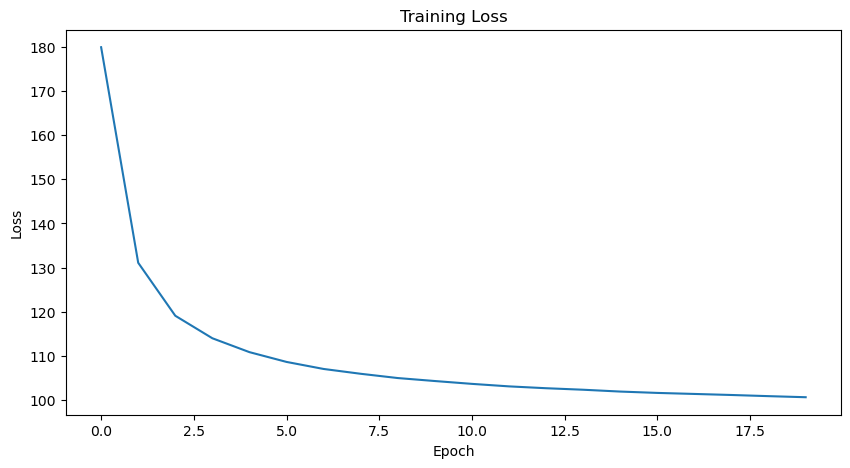

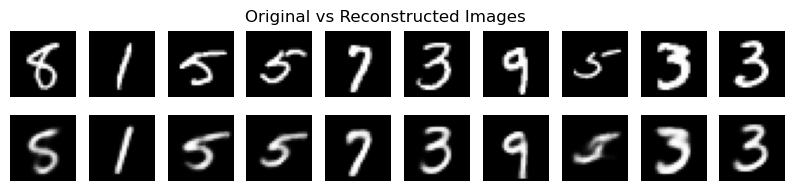

Generating new samples...


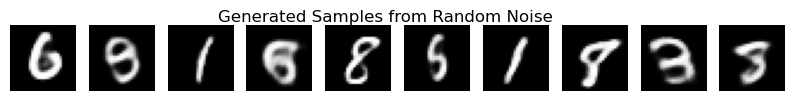

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 设置设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 1. 定义VAE模型
class VAE(nn.Module):
    def __init__(self, image_size=784, h_dim=400, z_dim=20):
        """
        image_size: 输入图像大小，MNIST是28*28=784
        h_dim: 编码器隐藏层维度
        z_dim: 潜在空间维度
        """
        super(VAE, self).__init__()
        
        # 编码器
        self.encoder = nn.Sequential(
            nn.Linear(image_size, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, h_dim//2),
            nn.ReLU(),
        )
        
        # 均值和对数方差的线性层
        self.fc_mu = nn.Linear(h_dim//2, z_dim)
        self.fc_logvar = nn.Linear(h_dim//2, z_dim)
        
        # 解码器
        self.decoder = nn.Sequential(
            nn.Linear(z_dim, h_dim//2),
            nn.ReLU(),
            nn.Linear(h_dim//2, h_dim),
            nn.ReLU(),
            nn.Linear(h_dim, image_size),
            nn.Sigmoid()  # 输出在[0,1]之间，用于BCE损失
        )
    
    def encode(self, x):
        """将输入编码为潜在分布的参数"""
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """重参数化技巧"""
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        """从潜在变量解码重建图像"""
        return self.decoder(z)
    
    def forward(self, x):
        # 编码
        mu, logvar = self.encode(x)
        # 重参数化
        z = self.reparameterize(mu, logvar)
        # 解码
        recon_x = self.decode(z)
        return recon_x, mu, logvar

# 2. 定义损失函数
def loss_function(recon_x, x, mu, logvar):
    """
    VAE损失函数 = 重建损失 + KL散度
    """
    # 重建损失 - 二元交叉熵
    # 因为MNIST是二值化的，使用BCE更合适
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    
    # KL散度 - 让潜在分布接近标准正态分布
    # 公式: -0.5 * sum(1 + log(sigma^2) - mu^2 - sigma^2)
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    return BCE + KLD, BCE, KLD

# 3. 数据准备
def get_data_loader(batch_size=128):
    transform = transforms.Compose([
        transforms.ToTensor(),
        # 将图像展平为向量
        transforms.Lambda(lambda x: x.view(-1))
    ])
    
    train_dataset = datasets.MNIST(
        root='./data', 
        train=True, 
        download=True, 
        transform=transform
    )
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True
    )
    
    return train_loader

# 4. 训练函数
def train_vae(model, train_loader, epochs=50):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    
    train_losses = []
    
    for epoch in range(epochs):
        total_loss = 0
        total_bce = 0
        total_kld = 0
        
        for batch_idx, (data, _) in enumerate(train_loader):
            data = data.to(device)
            optimizer.zero_grad()
            
            # 前向传播
            recon_batch, mu, logvar = model(data)
            
            # 计算损失
            loss, bce, kld = loss_function(recon_batch, data, mu, logvar)
            
            # 反向传播
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_bce += bce.item()
            total_kld += kld.item()
            
            if batch_idx % 100 == 0:
                print(f'Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                      f'({100. * batch_idx / len(train_loader):.0f}%)]'
                      f'\tLoss: {loss.item() / len(data):.4f}')
        
        avg_loss = total_loss / len(train_loader.dataset)
        avg_bce = total_bce / len(train_loader.dataset)
        avg_kld = total_kld / len(train_loader.dataset)
        
        train_losses.append(avg_loss)
        
        print(f'====> Epoch: {epoch} Average loss: {avg_loss:.4f}, '
              f'BCE: {avg_bce:.4f}, KLD: {avg_kld:.4f}')
    
    return train_losses

# 5. 可视化结果函数
def visualize_results(model, test_loader, num_samples=10):
    """可视化重建结果和生成新样本"""
    model.eval()
    
    with torch.no_grad():
        # 获取一批测试数据
        data, _ = next(iter(test_loader))
        data = data.to(device)
        
        # 重建
        recon_data, _, _ = model(data)
        
        # 绘制原始图像和重建图像
        fig, axes = plt.subplots(2, num_samples, figsize=(num_samples, 2))
        
        for i in range(num_samples):
            # 原始图像
            axes[0, i].imshow(data[i].cpu().view(28, 28), cmap='gray')
            axes[0, i].axis('off')
            
            # 重建图像
            axes[1, i].imshow(recon_data[i].cpu().view(28, 28), cmap='gray')
            axes[1, i].axis('off')
        
        axes[0, 0].set_ylabel('Original')
        axes[1, 0].set_ylabel('Reconstructed')
        plt.suptitle('Original vs Reconstructed Images')
        plt.show()
        
        # 生成新样本
        print("Generating new samples...")
        z = torch.randn(num_samples, 20).to(device)  # 从标准正态分布采样
        generated = model.decode(z)
        
        fig, axes = plt.subplots(1, num_samples, figsize=(num_samples, 1))
        for i in range(num_samples):
            axes[i].imshow(generated[i].cpu().view(28, 28), cmap='gray')
            axes[i].axis('off')
        
        plt.suptitle('Generated Samples from Random Noise')
        plt.show()

# 6. 主函数
def main():
    # 超参数
    batch_size = 128
    epochs = 20
    z_dim = 20
    learning_rate = 1e-3
    
    # 获取数据
    train_loader = get_data_loader(batch_size)
    
    # 准备测试数据用于可视化
    test_dataset = datasets.MNIST(
        root='./data', 
        train=False, 
        download=True, 
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x.view(-1))
        ])
    )
    test_loader = DataLoader(test_dataset, batch_size=10, shuffle=True)
    
    # 初始化模型
    model = VAE(z_dim=z_dim).to(device)
    print(f"Model initialized with {sum(p.numel() for p in model.parameters())} parameters")
    
    # 训练模型
    print("Starting training...")
    train_losses = train_vae(model, train_loader, epochs)
    
    # 绘制训练损失
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()
    
    # 可视化结果
    visualize_results(model, test_loader)

if __name__ == "__main__":
    main()